# Задание к лекции №8

**Тема**: Корреляционно-регрессионный анализ

In [1]:
# Подготовка зависимостей
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

Ответить на вопросы и прикрепить на проверку:

1. Что такое корреляция? Свойства коэффициента корреляции.

**Ответ**:

**Корреляция** — это мера линейной взаимосвязи между двумя величинами.

**Свойства коэффициента корреляции:**

1. **Изменяется от -1 до 1.**
Причём чем ближе коэффициент корреляции по модулю к 1, тем сильнее связь. Ориентировочно можно делать выводы согласно классификации, которую предложил математик Чеддок:
   - слабая — от 0.1 до 0.3;
   - умеренная — от 0.3 до 0.5;
   - заметная — от 0.5 до 0.7;
   - высокая — от 0.7 до 0.9;
   - весьма высокая (сильная) — от 0.9 до 1.0.

2. **Положительный коэффициент корреляции свидетельствует о прямой зависимости.**
То есть, когда значение одного признака увеличивается, то значение другого тоже увеличивается.

3. **Отрицательный коэффициент корреляции свидетельствует об обратной зависимости.**
То есть, когда значение одного признака увеличивается, то значение другого уменьшается.

Домножение переменной на положительную константу или прибавление константы никак не меняет коэффициент корреляции и силу связи. В случае домножения на отрицательную константу коэффициент корреляции меняет знак, но сила взаимосвязи остаётся прежней.

2. Формула вычисления коэффициента корреляции. Реализуйте формулу на Python и проверьте результаты вычислений по данным примера на стр. 4.

**Ответ**: Для оценки силы и направления линейной взаимосвязи рассчитывается коэффициент корреляции Пирсона (обозначается маленькой буквой r) по следующей формуле:

$$r = \frac{\sum(x - M_x) \cdot (y - M_y)}{\sqrt{\sum(x - M_x)^2 \cdot \sum(y - M_y)^2}}$$

Данные примера со стр. 4:

| X | Y |
|---|---|
| 2 | 6 |
| 4 | 8 |
| 1 | 1 |
| 3 | 7 |
| 5 | 3 |

Ожидаемый результат: r ≈ 0.33

In [2]:
X = [2, 4, 1, 3, 5]
Y = [6, 8, 1, 7, 3]

Mx = sum(X) / len(X)
My = sum(Y) / len(Y)

numerator = sum((x - Mx) * (y - My) for x, y in zip(X, Y))
sum_sq_x = sum((x - Mx) ** 2 for x in X)
sum_sq_y = sum((y - My) ** 2 for y in Y)

r = numerator / math.sqrt(sum_sq_x * sum_sq_y)

print(f"Mx = {Mx}")
print(f"My = {My}")
print(f"Сумма произведений отклонений = {numerator}")
print(f"Сумма квадратов отклонений X = {sum_sq_x}")
print(f"Сумма квадратов отклонений Y = {sum_sq_y}")
print(f"Коэффициент корреляции r = {r:.2f}")

Mx = 3.0
My = 5.0
Сумма произведений отклонений = 6.0
Сумма квадратов отклонений X = 10.0
Сумма квадратов отклонений Y = 34.0
Коэффициент корреляции r = 0.33


3. Интерпретация корреляции.

**Ответ**: Важно понимать, что корреляция свидетельствует именно о взаимосвязи, но ни в коем случае нельзя делать на основе корреляционного анализа выводы о причинно-следственных связях. Если между признаками А и Б есть тесная взаимосвязь, то мы не можем говорить, что А влияет на Б или Б влияет на А.

Корреляционный анализ применяется в следующих практических задачах:
- **Для прогнозирования.** Если мы знаем, что две переменные связаны определённым образом, то мы можем прогнозировать значение одной по значению другой. Однако такой прогноз будет не совсем точен. Более корректные предсказания можно делать на основании регрессионных моделей.
- **Для оценки валидности разных тестов.** Например, если психолог разработал тест для определения уровня тревоги, то его результаты должны показывать сильную корреляцию с другими показателями, которые точно идентифицируют тревожность.
- **Для вычисления надёжности оценочных инструментов.** Если корреляция между результатами, полученными при повторном проведении теста, сильная, то можно говорить о надёжности инструмента.

4. Визуальный анализ наличия зависимостей в данных: диаграммы `scatterplot`, `regplot`, `swarmplot`, `pairplot`. Назначение каждого вида диаграмм и пример использования на своих данных.

**Ответ**:

- **scatterplot** — диаграмма разброса. По одной оси отложены значения одной характеристики, по другой — значения второй характеристики. Подходит для отображения двух числовых характеристик. Создаётся с помощью функции `scatterplot` из библиотеки Seaborn; в аргументах указываются последовательности значений по осям X и Y (либо DataFrame и имена колонок).

- **regplot** — диаграмма разброса с линией и доверительным интервалом. Через точки проводят линию для проверки наличия линейной зависимости; доверительный интервал — диапазон вокруг линии, в котором находится большая часть точек набора. Подходит для двух числовых характеристик. Создаётся функцией `regplot` из библиотеки Seaborn.

- **swarmplot** — диаграмма, используемая в случае визуализации категориальных характеристик. Автоматически отображает точки без наложения, позволяя оценить, где находится основная часть значений. Необходимо передать функции `swarmplot` данные, которые будут отображаться по осям X и Y. Не подходит для отображения большого количества точек.

- **pairplot** — визуализация зависимостей в данных, представляющая собой таблицу из нескольких графиков. В недиагональных элементах расположены диаграммы разброса, по диагонали — графики распределения значений. Строится с помощью функции `pairplot()`, в которую можно передать исходный DataFrame без дополнительных преобразований. Следует использовать только при небольшом количестве анализируемых характеристик, так как обрабатывает данные довольно долго.

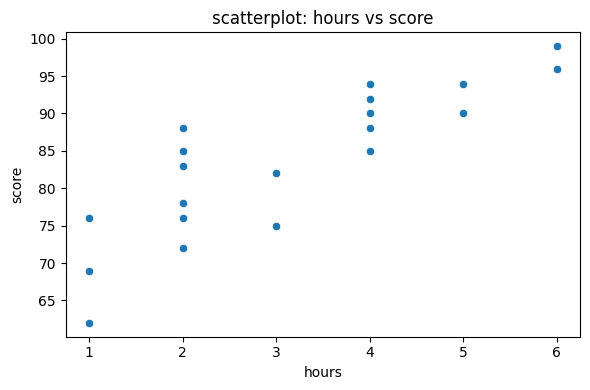

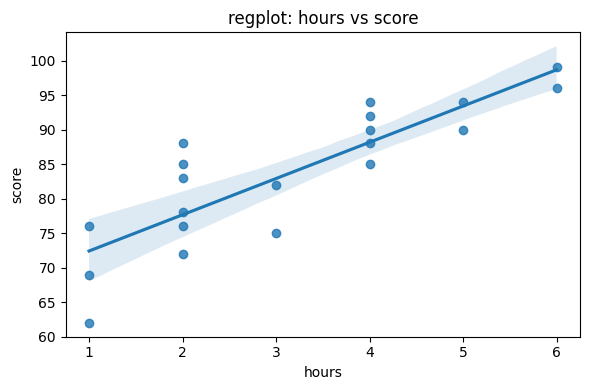

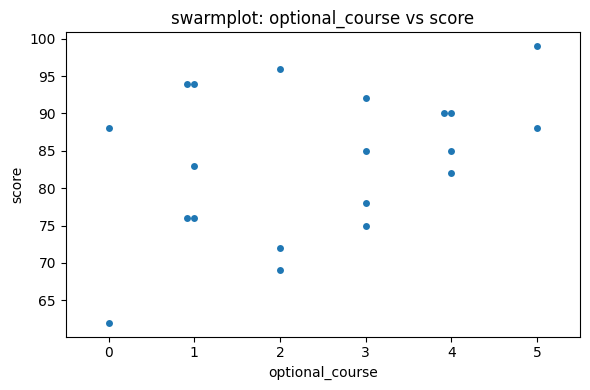

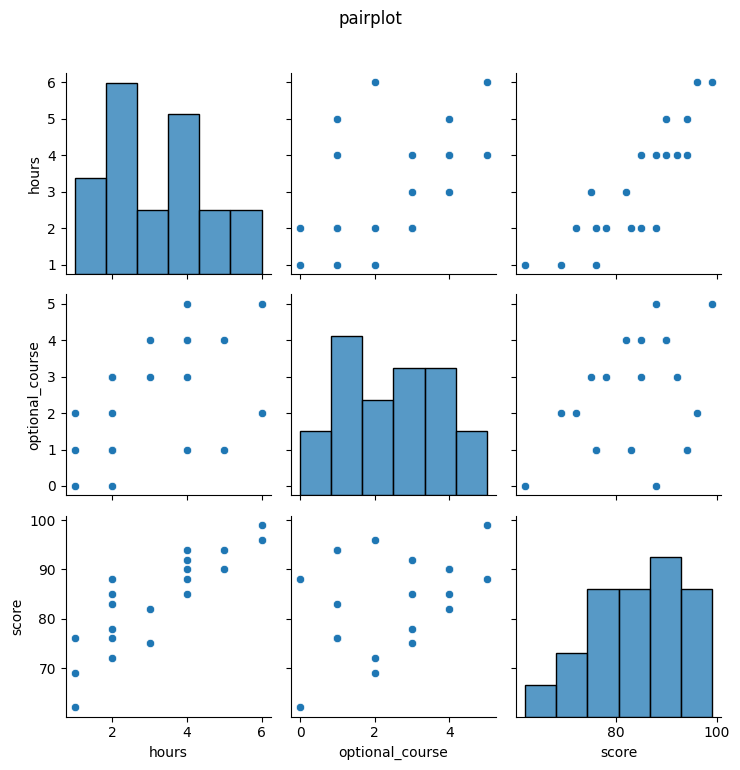

In [3]:
df = pd.read_csv('exams.csv', index_col=0)

# scatterplot
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='hours', y='score')
plt.title('scatterplot: hours vs score')
plt.tight_layout()
plt.show()

# regplot
plt.figure(figsize=(6, 4))
sns.regplot(data=df, x='hours', y='score')
plt.title('regplot: hours vs score')
plt.tight_layout()
plt.show()

# swarmplot (optional_course — категориальный по смыслу)
plt.figure(figsize=(6, 4))
sns.swarmplot(data=df, x='optional_course', y='score')
plt.title('swarmplot: optional_course vs score')
plt.tight_layout()
plt.show()

# pairplot
pairplot_fig = sns.pairplot(df)
pairplot_fig.figure.suptitle('pairplot', y=1.02)
plt.tight_layout()
plt.show()

5. Вычисление корреляции в Pandas.

**Ответ**: В библиотеке pandas корреляция вычисляется с помощью метода `.corr()`. Эта функция автоматически рассчитывает корреляции между всеми числовыми колонками, а категориальные колонки не учитывает.

In [4]:
df = pd.read_csv('exams.csv', index_col=0)

corr_matrix = df.corr()
print(corr_matrix)

                    hours  optional_course     score
hours            1.000000         0.516303  0.852791
optional_course  0.516303         1.000000  0.369810
score            0.852791         0.369810  1.000000


6. Построение коррелограммы.

**Ответ**: Тепловая карта, которая отображает значения корреляции, называется коррелограммой. Чтобы построить коррелограмму в seaborn, необходимо в функцию `heatmap` передать:
- матрицу корреляции, полученную с помощью метода `corr()`;
- параметр `vmin = -1`;
- параметр `vmax = 1`;
- параметр `cmap` для выбора цветовой палитры;
- параметр `annot = True` для отображения значений и `fmt` с кодом формата чисел, например `'.2f'`.

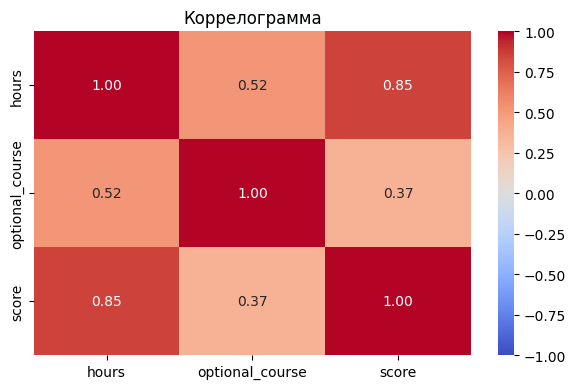

In [5]:
df = pd.read_csv('exams.csv', index_col=0)

corr_matrix = df.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Коррелограмма')
plt.tight_layout()
plt.show()

7. Понятие линейной регрессии, интерпретация коэффициентов.

**Ответ**: Уравнение простой линейной регрессии имеет следующий вид:

$$y = b_0 + b_1 \cdot x$$

У нас есть признак X (независимый предиктор) и признак y (целевая зависимая переменная). По этим массивам данных мы хотим восстановить коэффициенты, чтобы в будущем иметь возможность предсказывать зависимую переменную.

Полученное уравнение называют **уравнением регрессии**. При решении реальных задач не получится найти точное уравнение, потому что на каждый признак влияет множество других, а также различные случайные факторы. Поэтому мы можем получить лишь приблизительные уравнения.

Например, у нас есть зависимость цены квартиры (в миллионах рублей) от её площади:

$$y(\text{цена квартиры}) = 0.04 \cdot X(\text{площадь}) + 2.4$$

По такой зависимости можно вычислить, что квартира площадью 50 квадратных метров будет стоить 4.4 млн рублей:

$$y = 0.04 \cdot 50 + 2.4 = 2 + 2.4 = 4.4$$

Важно помнить, что предсказания всегда неидеальны, и в них будет какая-то ошибка — когда-то меньшая, когда-то большая. В целом, величина ошибки будет связана с силой корреляционной связи между двумя переменными (чем коэффициент корреляции ближе к единице по модулю, тем меньше ошибка). Также значения, для которых мы делаем предсказания, должны быть из того же диапазона, что и значения, для которых мы получили уравнение регрессии.

8. Алгоритм нахождения коэффициентов линейной регрессии по методу наименьших квадратов.

**Ответ**: Нашей задачей является нахождение такой функции, которая при предсказании новых данных будет ошибаться меньше всех других. Для этого находим все отклонения между реальными данными и предсказанными:

$$y - \hat{y}$$

Так как отклонения могут быть отрицательными и положительными, мы будем искать сумму квадратов отклонений, чтобы минусы превратились в плюсы:

$$\sum(y - \hat{y})^2$$

Оптимальной функцией будет та, для которой сумма квадратов ошибок будет наименьшей. Именно поэтому данный метод называется **методом наименьших квадратов**.

Для нахождения коэффициентов уравнения $y = a \cdot x + b$ используются следующие формулы:

$$a = \frac{\sum_{i=1}^{n}(x_i - \bar{x}) \cdot (y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

$$b = \bar{y} - a \cdot \bar{x}$$

**Алгоритм:**
1. Вычислить средние значения $\bar{x}$ и $\bar{y}$.
2. Найти отклонения каждого значения от среднего: $(x_i - \bar{x})$ и $(y_i - \bar{y})$.
3. Вычислить квадраты отклонений $(x_i - \bar{x})^2$ и произведения отклонений $(x_i - \bar{x}) \cdot (y_i - \bar{y})$.
4. Найти сумму произведений отклонений и сумму квадратов отклонений для независимой переменной.
5. Найти коэффициент $a$ по формуле выше.
6. Найти коэффициент $b$ по формуле выше.

9. Программная реализация нахождения коэффициентов для модели линейной регрессии вида: `y = a*x+b`. Выполните проверку на данных примера зависимости стоимости квартиры от площади стр. 20.

**Ответ**:

Данные примера со стр. 20 (зависимость стоимости квартиры от площади):

| Площадь | Стоимость |
|---------|-----------|
| 35      | 3         |
| 51      | 6         |
| 43      | 3         |
| 38      | 5         |
| 68      | 8         |
| 66      | 5         |
| 49      | 6         |
| 50      | 4         |

Ожидаемый результат: a = 0.098, b = 0.1, уравнение: Цена = 0.098 * Площадь + 0.1

In [6]:
# Данные примера стр. 20
X = [35, 51, 43, 38, 68, 66, 49, 50]
Y = [3, 6, 3, 5, 8, 5, 6, 4]

x_mean = sum(X) / len(X)
y_mean = sum(Y) / len(Y)

numerator = sum((xi - x_mean) * (yi - y_mean) for xi, yi in zip(X, Y))
denominator = sum((xi - x_mean) ** 2 for xi in X)

a = numerator / denominator
b = y_mean - a * x_mean

print(f"x_mean = {x_mean}")
print(f"y_mean = {y_mean}")
print(f"Сумма произведений отклонений = {numerator}")
print(f"Сумма квадратов отклонений X = {denominator}")
print(f"a = {a:.3f}")
print(f"b = {b:.3f}")
print(f"Уравнение регрессии: Цена = {a:.3f} * Площадь + {b:.3f}")

# Проверка: предсказание для площади 60 кв.м
x_new = 60
y_pred = a * x_new + b
print(f"\nПредсказанная цена для площади {x_new} кв.м: {y_pred:.2f} млн руб.")

x_mean = 50.0
y_mean = 5.0
Сумма произведений отклонений = 98.0
Сумма квадратов отклонений X = 1000.0
a = 0.098
b = 0.100
Уравнение регрессии: Цена = 0.098 * Площадь + 0.100

Предсказанная цена для площади 60 кв.м: 5.98 млн руб.


10. Метрики оценки качества линейной регрессии.

**Ответ**:

**MSE (среднеквадратичная ошибка, mean squared error)** — вычисляется как сумма квадратов ошибок, делённая на количество наблюдений. Так как величина этой ошибки является относительной и зависит от единиц измерения целевой переменной, у нас нет чёткого порога, разделяющего модели с хорошей и плохой предсказательной способностью. Однако с помощью MSE можно сравнивать разные модели — наилучшей будет та, у которой значение MSE меньше.

$$MSE = \frac{\sum(y - \hat{y})^2}{n}$$

**MAE (средняя абсолютная ошибка, mean absolute error)** — вычисляется как сумма модулей ошибок, делённая на количество наблюдений. В отличие от MSE, вместо возведения в квадрат берутся модули отклонений.

$$MAE = \frac{\sum|y - \hat{y}|}{n}$$

**Коэффициент детерминации** — также упоминается в лекции как один из показателей качества модели (выводится методом `summary()` в statsmodels).

11. Множественная линейная регрессия: вид уравнения и описание модели.

**Ответ**:

Уравнение линейной регрессии имеет вид:

$$y = b_0 + b_1 \cdot x_1 + b_2 \cdot x_2$$

Например, зависимость цены от площади и удалённости в минутах выражается следующим образом:

$$\text{Цена} = 0.036546 \cdot \text{Площадь} - 0.332182 \cdot \text{Минуты} + 6.162323$$

Для нахождения коэффициентов уравнения множественной регрессии с двумя предикторами используются формулы:

$$b_1 = \frac{\sum(x_{1i}-\bar{x_1})\cdot(y_i-\bar{y}) \cdot \sum(x_{2i}-\bar{x_2})^2 - \sum(x_{2i}-\bar{x_2})\cdot(y_i-\bar{y}) \cdot \sum(x_{1i}-\bar{x_1})\cdot(x_{2i}-\bar{x_2})}{\sum(x_{1i}-\bar{x_1})^2 \cdot \sum(x_{2i}-\bar{x_2})^2 - [\sum(x_{1i}-\bar{x_1})\cdot(x_{2i}-\bar{x_2})]^2}$$

$$b_2 = \frac{\sum(x_{2i}-\bar{x_2})\cdot(y_i-\bar{y}) \cdot \sum(x_{1i}-\bar{x_1})^2 - \sum(x_{1i}-\bar{x_1})\cdot(y_i-\bar{y}) \cdot \sum(x_{1i}-\bar{x_1})\cdot(x_{2i}-\bar{x_2})}{\sum(x_{1i}-\bar{x_1})^2 \cdot \sum(x_{2i}-\bar{x_2})^2 - [\sum(x_{1i}-\bar{x_1})\cdot(x_{2i}-\bar{x_2})]^2}$$

$$b_0 = \bar{y} - b_1 \cdot \bar{x_1} - b_2 \cdot \bar{x_2}$$

Нахождение коэффициентов множественной регрессии является довольно затратным с вычислительной точки зрения процессом, поэтому в практической части такие уравнения рассчитываются исключительно с использованием компьютерных программ.

12. Предпосылки линейной регрессии.

**Ответ**: Модель линейной регрессии можно построить не для любых данных, а только для данных, которые удовлетворяют ряду условий. Прежде чем использовать регрессионное уравнение для прогнозирования, необходимо проверить выполнение этих условий.

1. **Линейная зависимость.** Предполагается корректность модели, выбор адекватных предикторов и отсутствие лишних предикторов, а также линейная зависимость целевой переменной от независимых переменных.

2. **Гомоскедастичность.** Разброс остатков при любых значениях независимых переменных одинаковый. Важно, чтобы качество модели было одно и то же при любых значениях независимой переменной.

3. **Отсутствие мультиколлинеарности.** Мультиколлинеарность — это явление, заключающееся в наличии линейной зависимости между независимыми переменными (предикторами). Последствием мультиколлинеарности является расширение доверительных интервалов для коэффициентов, и модель получается очень неустойчивой и меняющейся от добавления даже 1–2 новых наблюдений. Для проверки необходимо построить матрицу корреляций для всех потенциальных предикторов и отследить наличие сильной корреляционной связи (граница около 0.9).

4. **Нормальное распределение ошибок.** Распределение остатков (разниц между реальным значением y и предсказанным) должно стремиться к нормальному распределению. Проверить можно визуально с помощью гистограммы или с помощью специальных статистических тестов.

5. **Отсутствие автокорреляции остатков.** Автокорреляция остатков возникает в ситуации, когда есть линейная взаимосвязь между остатками для одних значений предикторов и остатками для других значений предикторов. Автокорреляция влечёт за собой некорректные результаты: стандартные ошибки получаются несостоятельными, и нельзя строить корректные доверительные интервалы и проверять гипотезы классическими способами.

13. Способы построения модели линейной регрессии в Python.

**Ответ**: В лекции описаны два способа построения модели линейной регрессии в Python:

1. **С помощью пакета statsmodels.**
   - Данные сохраняются в две переменные X (независимые переменные) и Y (зависимая переменная).
   - С помощью метода `sm.add_constant()` добавляется константа (техническое действие, без которого результаты моделирования будут некорректными).
   - Создаётся объект модели, затем с помощью метода `fit()` вычисляется наилучшая регрессионная линия.
   - Результаты сохраняются и выводятся с помощью метода `summary()`.
   - Отдельно можно вывести коэффициенты модели.

2. **С помощью библиотеки sklearn.**
   - Модель линейной регрессии строится с использованием инструментов библиотеки sklearn.

14. Постройте модель линейной регрессии для следующей задачи: предположим, мы хотим знать, влияет ли количество часов, потраченных на подготовку, и количество посещенных факультативов на оценку, которую студент получает на определенном экзамене. Выведите получившиеся коэффициенты линейной модели, оцените качество модели с использованием различных метрик. Попробуйте предсказать оценку за экзамен для студента, который потратил 8 часов на подготовку и посещал в течении семестра 2 факультатива. Перед построением модели проведите предварительный визуальный анализ данных с использованием диаграмм п.4. Данные для анализа находятся в файле [exams.csv](exams.csv).

1 - Загрузка данных из файла exams.csv.

In [7]:
df = pd.read_csv('exams.csv', index_col=0)
df

,hours,optional_course,score
0,1,1,76
1,2,3,78
2,2,3,85
3,4,5,88
4,2,2,72
5,1,2,69
6,5,1,94
7,4,1,94
8,2,0,88
9,4,3,92


2 - Предварительный визуальный анализ (scatterplot, regplot, swarmplot, pairplot).

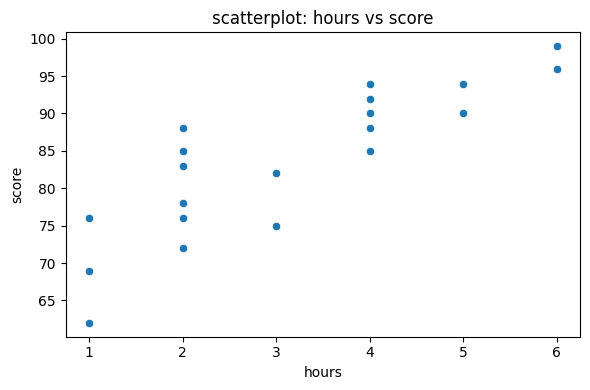

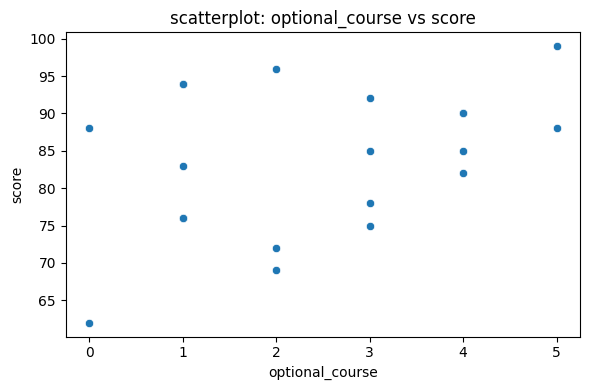

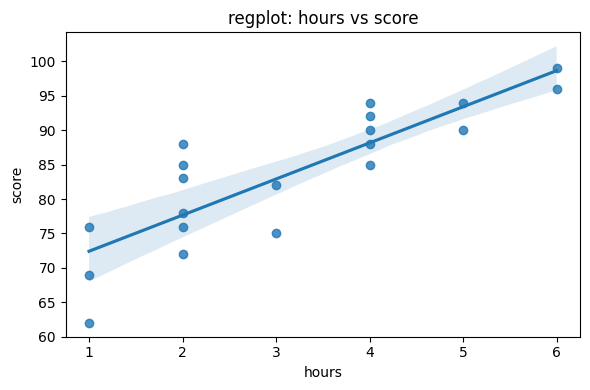

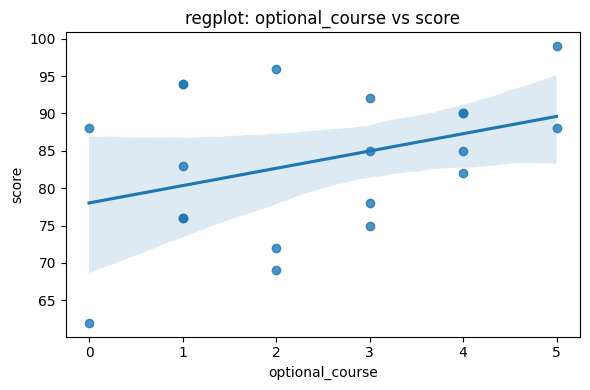

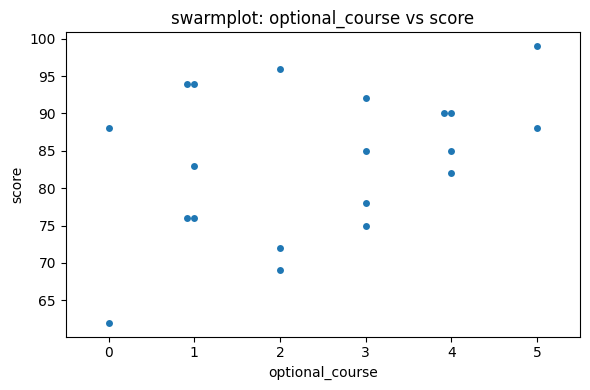

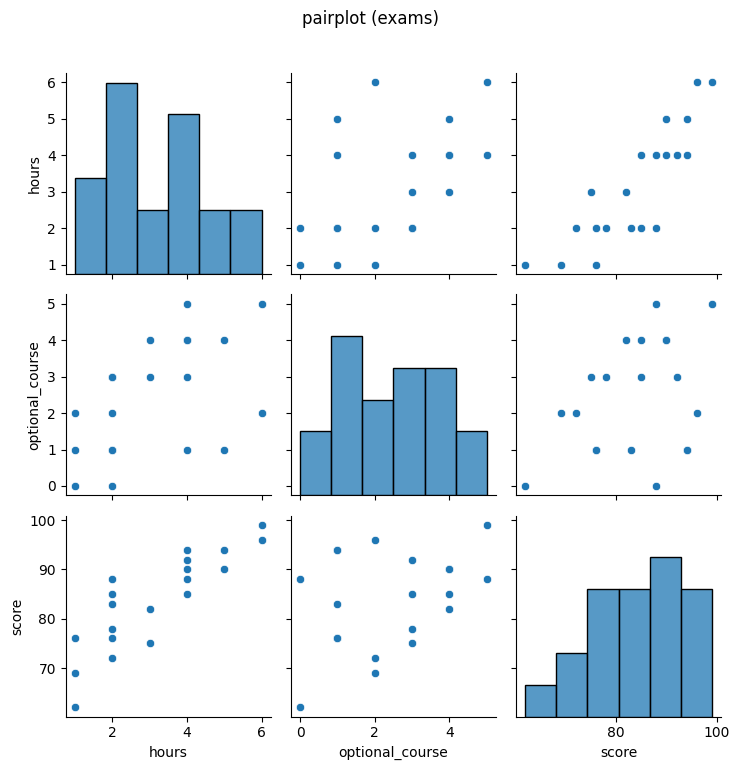

In [8]:
# scatterplot: hours vs score
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='hours', y='score')
plt.title('scatterplot: hours vs score')
plt.tight_layout()
plt.show()

# scatterplot: optional_course vs score
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='optional_course', y='score')
plt.title('scatterplot: optional_course vs score')
plt.tight_layout()
plt.show()

# regplot: hours vs score
plt.figure(figsize=(6, 4))
sns.regplot(data=df, x='hours', y='score')
plt.title('regplot: hours vs score')
plt.tight_layout()
plt.show()

# regplot: optional_course vs score
plt.figure(figsize=(6, 4))
sns.regplot(data=df, x='optional_course', y='score')
plt.title('regplot: optional_course vs score')
plt.tight_layout()
plt.show()

# swarmplot: optional_course vs score
plt.figure(figsize=(6, 4))
sns.swarmplot(data=df, x='optional_course', y='score')
plt.title('swarmplot: optional_course vs score')
plt.tight_layout()
plt.show()

# pairplot
pairplot_fig = sns.pairplot(df)
pairplot_fig.figure.suptitle('pairplot (exams)', y=1.02)
plt.tight_layout()
plt.show()

3 - Построение модели множественной линейной регрессии с помощью statsmodels и sklearn.

In [9]:
# Построение модели (statsmodels)

X = df[['hours', 'optional_course']]
Y = df['score']

X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const)
results = model.fit()
print(results.summary())
print("Коэффициенты модели (statsmodels):\n", results.params)

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     23.46
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           1.29e-05
Time:                        23:49:03   Log-Likelihood:                -60.354
No. Observations:                  20   AIC:                             126.7
Df Residuals:                      17   BIC:                             129.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              67.6735      2.816     

In [10]:
# Построение модели (sklearn)

lr = LinearRegression()
lr.fit(X, Y)
print(f"Коэффициенты модели (sklearn):")
print(f"  Intercept (b0): {lr.intercept_:.4f}")
print(f"  hours (b1):     {lr.coef_[0]:.4f}")
print(f"  optional_course (b2): {lr.coef_[1]:.4f}")

Коэффициенты модели (sklearn):
  Intercept (b0): 67.6735
  hours (b1):     5.5557
  optional_course (b2): -0.6017


4 - Вывод коэффициентов и оценка качества модели (MSE, MAE, R²).

In [11]:
Y_pred = lr.predict(X)
mse = metrics.mean_squared_error(Y, Y_pred)
mae = metrics.mean_absolute_error(Y, Y_pred)
r2  = metrics.r2_score(Y, Y_pred)

print(f"Метрики качества модели:")
print(f"  MSE  = {mse:.4f}")
print(f"  MAE  = {mae:.4f}")
print(f"  R²   = {r2:.4f}")

Метрики качества модели:
  MSE  = 24.4722
  MAE  = 3.9746
  R²   = 0.7340


5 - Предсказание оценки для студента с 8 часами подготовки и 2 факультативами.

In [12]:
new_student = pd.DataFrame({'hours': [8], 'optional_course': [2]})
predicted_score = lr.predict(new_student)
print(f"Предсказанная оценка для студента (8 часов, 2 факультатива): {predicted_score[0]:.2f}")

Предсказанная оценка для студента (8 часов, 2 факультатива): 110.92


In [13]:
# Экспорт в html
import subprocess
subprocess.run(["jupyter", "nbconvert", "--to", "html", __vsc_ipynb_file__.split("/")[-1]])

[NbConvertApp] Converting notebook questions8.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Writing 669259 bytes to questions8.html


CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', 'questions8.ipynb'], returncode=0)